# Project 2 - Part 2: Extended Modelling

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### **Effect of vaccination**

In [59]:
#%% Plotting parameters
plt.rcParams.update({
    "font.size": 14,        # default text
    "axes.titlesize": 20,   # subplot titles
    "axes.labelsize": 18,   # axis labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 18
})

In [60]:
#%% Functions

# SIR ODE system (with vaccination)
def sir_ode_v(t, y, beta, gamma, rho, e):
    S, I, R, V = y
    N = S + I + R + V
    
    dSdt = - beta/N * I * S - rho * e * S
    dIdt = beta/N * I * S - gamma * I
    dRdt = gamma * I
    dVdt = rho * e * S

    return (dSdt, dIdt, dRdt, dVdt)


# CTMC SIR (with vaccination included) simulation function
def simulate_sir_ctmc_v(N, beta, gamma, rho, e, I0=1, R0=0, V0=0, t_max=100, seed=None):
    
    # Set seed for reproducibility (if seed is not None)
    if seed is not None:
        np.random.seed(seed)

    # Initial condition
    S = N - I0 - R0 - V0
    I = I0
    R = R0
    V = V0
    t = 0

    # Initialize lists to save results
    times = [t]
    S_values = [S]
    I_values = [I]
    R_values = [R]
    V_values = [V]

    # Run simulation until time limit 
    while t < t_max:

        # Compute event rates
        I_rate = beta * S * I / N # rate of getting infected 
        R_rate = gamma * I # rate of recovering
        V_rate = rho * e * S # rate of successful vaccination
        rates = np.array([I_rate, R_rate, V_rate]) # list of all rates
        total_rate = rates.sum() # total rate of leaving the current state

        # If no people move between compartments, break
        if total_rate == 0:
            break

        # Time to next event
        dt = np.random.exponential(scale=1 / total_rate) # Exponentially distributed
        t += dt

        # Choose event type
        E = np.random.choice(len(rates), p=rates/total_rate)

        if E == 0:
            # Infection: S -> I
            S -= 1
            I += 1
        elif E == 1:
            # Recovery: I -> R
            I -= 1
            R += 1
        elif E == 2:
            # Successful vaccination: S --> V
            S -= 1
            V += 1
            
        # Save results
        times.append(t)
        S_values.append(S)
        I_values.append(I)
        R_values.append(R)
        V_values.append(V)

    return np.array(times), np.array(S_values), np.array(I_values), np.array(R_values), np.array(V_values)

No vaccination:
Epidemic peak = 2550.1193460409963
e = 0.3:
Epidemic peak = 1782.590302879671
e = 0.6:
Epidemic peak = 1349.6572261260249
e = 0.9:
Epidemic peak = 1107.848952791393


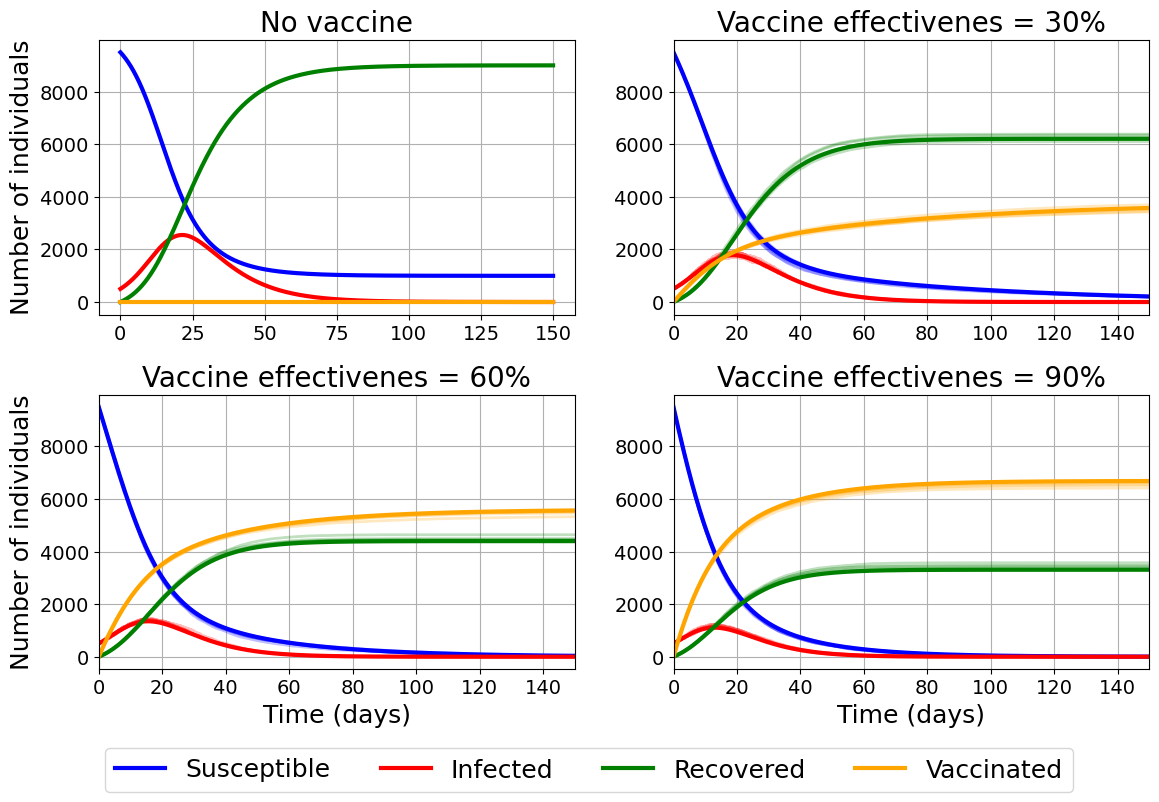

In [61]:
#%% Run simulation: Vaccine effectiveness

# Parameters
n_reps = 5 # Number of repetitions of the simulation 
N = 10000 # Population size 
I0 = 0.05*N # Initial number of infected
R0 = 0 # Initial number of recovered
V0 = 0 # Initial number of successfully vaccinated
S0 = N - I0 - R0 # Initial number of susceptible 
diseases = ["Seasonal Influenza", "COVID-19", "Ebola"]
betas = np.array([0.5, 0.25, 0.15]) # beta values for each disease
gammas = np.array([0.33, 0.1, 0.1]) # gamma values for each disease
rho = 0.05 # vaccination rate
es = [0.3, 0.6, 0.9] # vaccine effectiveness 

# Pick which disease
disease_idx = 1
beta = betas[disease_idx]
gamma = gammas[disease_idx]

# Time interval
t_start = 0 
t_end = 150 
t_vals = np.linspace(t_start, t_end, 1000)

# Setup plot
#fig, ax = plt.subplots(1,len(es)+1, figsize=(15,5))
fig, ax = plt.subplots(2, 2, figsize=(12,8))
ax = ax.flatten()

# No vaccination for comparison
sol = solve_ivp(fun=sir_ode_v, t_span=(t_start, t_end), y0=[S0, I0, R0, V0], args=[beta, gamma, rho, 0], t_eval=t_vals)
S_det, I_det, R_det, V_det = sol.y
ax[0].plot(sol.t, S_det, color="b", linewidth=3, label="Susceptible")
ax[0].plot(sol.t, I_det, color="r", linewidth=3, label="Infected")
ax[0].plot(sol.t, R_det, color="g", linewidth=3, label="Recovered")
ax[0].plot(sol.t, V_det, color="orange", linewidth=3, label="Vaccinated")
ax[0].set_ylabel("Number of individuals")
ax[0].set_title(f"No vaccine")
ax[0].grid()
print(f"No vaccination:")
print(f"Epidemic peak = {np.max(I_det)}")

# Run experiment for each disease
for i, e in enumerate(es):

    #%% Deterministic ODE solution
    # Solve ODE system using solve_ivp (used to "Solve an initial value problem for a system of ODEs")
    sol = solve_ivp(fun=sir_ode_v, t_span=(t_start, t_end), y0=[S0, I0, R0, V0], args=[beta, gamma, rho, e], t_eval=t_vals)
    # Extract solution
    S_det, I_det, R_det, V_det = sol.y
    print(f"e = {e}:")
    print(f"Epidemic peak = {np.max(I_det)}")

    #%% Stochastic CTMC simulations
    times_all = []
    S_all = []
    I_all = []
    R_all = []
    V_all = []

    # Run simulations
    for j in range(n_reps):
        times, S, I, R, V = simulate_sir_ctmc_v(N, beta, gamma, rho, e, I0, R0, V0, t_end, seed=j)
        times_all.append(times)
        S_all.append(S)
        I_all.append(I)
        R_all.append(R)
        V_all.append(V)


    #%% Plot
    axis = ax[i+1]

    # CTMC realizations
    for times, S, I, R, V in zip(times_all, S_all, I_all, R_all, V_all):
        axis.plot(times, S, color="b", alpha=0.25, linewidth=2)
        axis.plot(times, I, color="r", alpha=0.25, linewidth=2)
        axis.plot(times, R, color="g", alpha=0.25, linewidth=2)
        axis.plot(times, V, color="orange", alpha=0.25, linewidth=2)

    # Deterministic ODE
    lineS, = axis.plot(sol.t, S_det, color="b", linewidth=3, label="Susceptible")
    lineI, = axis.plot(sol.t, I_det, color="r", linewidth=3, label="Infected")
    lineR, = axis.plot(sol.t, R_det, color="g", linewidth=3, label="Recovered")
    lineV, = axis.plot(sol.t, V_det, color="orange", linewidth=3, label="Vaccinated")

    axis.set_xlim(0, t_end)
    if i == 1:
        axis.set_ylabel("Number of individuals")
    if i == 1 or i == 2:
        axis.set_xlabel("Time (days)")
    axis.set_title(f"Vaccine effectivenes = {e*100:.0f}%")
    axis.grid()

# Add shared legend
fig.legend(
    [lineS, lineI, lineR, lineV],
    ["Susceptible", "Infected", "Recovered", "Vaccinated"],
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.02)
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [84]:
print(f"Reduction in epidemic peak from no vaccine to vaccine with 90% effectiveness: {(2550-1108)/2550}")

Reduction in epidemic peak from no vaccine to vaccine with 90% effectiveness: 0.5654901960784313
